# ECOMMERCE 2023

## Check Dataset

In [25]:
# Load dataset
import pandas as pd
df = pd.read_csv("../../Data/Extra/vietnam_ecommerce_2023.csv")

# Check structure
print("Check Shape:", df.shape)
print("\n Check Head:")
print(df.head().to_string())
print("\n Check Info:")
print(df.info())

# Missing Values Check
missing = df.isnull().sum()
missing_ratio = df.isnull().mean() * 100

print("\n Missing Values Count:")
print(missing)

print("\n Missing Values Ratio:")
print(missing_ratio)

Check Shape: (8000, 27)

 Check Head:
       order_id  order_date  month quarter day_of_week customer_id gender age_group      city    region channel payment_method          category  quantity  unit_price  gross_value  discount_pct  discount_amount  net_value  shipping_fee  free_shipping  total_paid  delivery_days  returned  rating campaign  profit
0  DH2023006817  2023-01-01      1      Q1      Sunday     KH00664    Nam       55+    Hà Nội  Miền Bắc     App            COD  Sách & Văn phòng         1       51028        51028          0.00                0      51028         25000          False       76028              2     False       5      NaN   -9692
1  DH2023002181  2023-01-01      1      Q1      Sunday     KH04895    Nam     25-34    Hà Nội  Miền Bắc     Web            COD  Đồ chơi & Trẻ em         2      316494       632988          0.15            94948     538040             0           True      538040              1     False       5      NaN  215216
2  DH2023007291  2023-0

# BÁO CÁO CEO: CHIẾN LƯỢC TẬP TRUNG NGÀNH HÀNG NÀO NĂM 2024?
**Mục tiêu:** Dựa trên số liệu 2023, báo cáo này làm rõ tại sao Doanh nghiệp cần cơ cấu lại tập trung vào các mặt hàng lợi nhuận cao, ít rủi ro và xác định ra ngành hàng "mỏ vàng" để dồn lực năm 2024.

## 1. Doanh thu vs Lợi nhuận biên theo ngành
**Headline:** Ngành hàng Làm đẹp có biên lợi nhuận cao — trong khi Điện tử doanh thu lớn nhưng biên lợi nhuận thấp.

💡 **Lựa chọn biểu đồ:**
- **Bubble chart (Scatter plot có kích thước hạt):** Biểu đồ tốt nhất khi cần so sánh cùng lúc 3 biến số: Doanh thu (trục X), Margin % (trục Y) và Thể tích đơn hàng (Kích cỡ bong bóng). Người xem dễ dàng nhận khoảng phân bố Quadrant (Doanh thu cao/thấp x Margin cao/thấp).

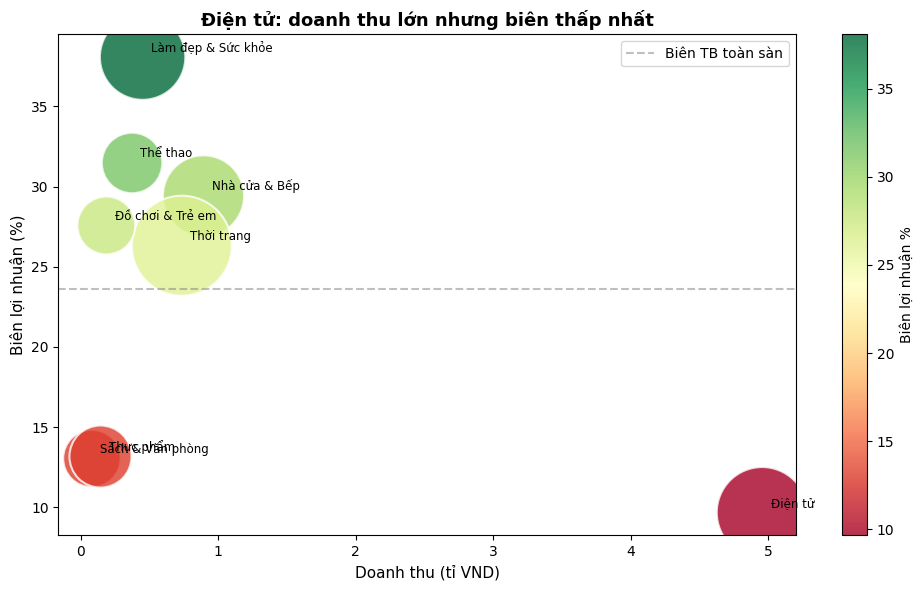

In [26]:
# Tính toán doanh thu, lợi nhuận và biên lợi nhuận theo ngành hàng
cat_stats = df.groupby('category').agg(
    revenue = ('net_value', 'sum'),
    profit = ('profit', 'sum'),
    orders = ('order_id', 'count')
).reset_index()

cat_stats['margin_pct'] = cat_stats['profit'] / cat_stats['revenue'] * 100

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    cat_stats['revenue'] / 1e9,
    cat_stats['margin_pct'],
    s=cat_stats['orders'] * 3,    # size = số đơn hàng
    c=cat_stats['margin_pct'],     # color = biên lợi nhuận
    cmap='RdYlGn', alpha=0.8, edgecolors='white', linewidth=1.5
)

# Label từng điểm
for _, row in cat_stats.iterrows():
    ax.annotate(row['category'], (row['revenue']/1e9, row['margin_pct']),
               textcoords='offset points', xytext=(6,4), fontsize=8.5)

# Đường tham chiếu
ax.axhline(y=cat_stats['margin_pct'].mean(), color='gray',
           linestyle='--', alpha=0.5, label='Biên TB toàn sàn')

ax.set_xlabel('Doanh thu (tỉ VND)', fontsize=11)
ax.set_ylabel('Biên lợi nhuận (%)', fontsize=11)
ax.set_title('Điện tử: doanh thu lớn nhưng biên thấp nhất', fontsize=13, fontweight='bold')
plt.colorbar(scatter, label='Biên lợi nhuận %')
plt.legend()
plt.tight_layout()
plt.show()

**👉 Kết luận & Call to Action**
- **Kết luận:** Điện tử đem lại nguồn tiền lớn nhưng đang ăn mòn nguồn lực với biên lợi nhuận thấp nhất, trong khi ngành Làm đẹp & Sức khỏe có biên lợi nhuận tuyệt vời.
- **Call to Action (Nên làm gì tiếp theo):** Tái phân bổ ngân sách: Giảm trợ giá/sponsoring cho Điện tử, tăng hiển thị cho ngành Làm đẹp và Thời trang ở trang chủ.
- **Big Idea:** Đừng chỉ nhìn vào doanh thu "ảo", biên lợi nhuận thực tế mới là điều giúp công ty sinh tồn.

## 2. Tỉ lệ hoàn hàng theo ngành
**Headline:** Tỉ lệ hoàn hàng Thời trang cao gấp nhiều lần so với các ngành khác, ăn mòn lợi nhuận.

💡 **Lựa chọn biểu đồ:**
- **Bar chart có Highlight:** Khi câu chuyện chỉ hướng về một category cá biệt (Thời trang), chúng ta sử dụng một Bar Chart sắp xếp tăng dần và duy nhất thanh hiển thị Thời trang được tô màu nóng (cam/đỏ). Kỹ thuật này lập tức đập vào mắt khán giả mà không gây nhiễu lượng.

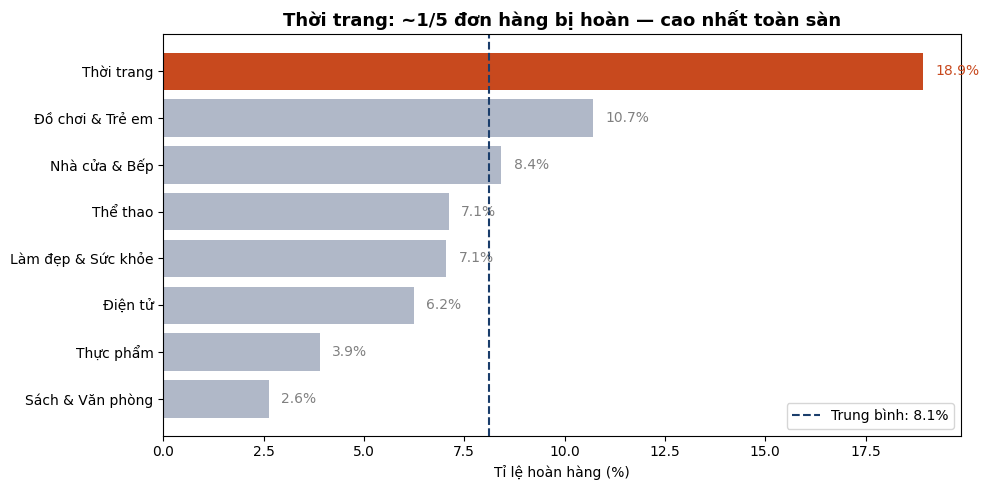

In [27]:
return_rate = df.groupby('category')['returned'].mean().sort_values(ascending=True)

colors = ['#C8491E' if cat == 'Thời trang' else '#B0B8C8' for cat in return_rate.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(return_rate.index, return_rate.values * 100, color=colors)

# Thêm số % lên từng bar
for bar, val in zip(bars, return_rate.values * 100):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10,
            color='#C8491E' if val == return_rate.max()*100 else 'gray')

# Đường benchmark
ax.axvline(x=return_rate.mean()*100, color='#1A3D6B',
           linestyle='--', label=f'Trung bình: {return_rate.mean()*100:.1f}%')

ax.set_title('Thời trang: ~1/5 đơn hàng bị hoàn — cao nhất toàn sàn',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tỉ lệ hoàn hàng (%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**👉 Kết luận & Call to Action**
- **Kết luận:** Tỷ lệ hoàn hàng của ngành Thời trang (xấp xỉ 20%) đang tạo ra chi phí ẩn logistics khổng lồ kéo tụt toàn bộ lợi nhuận.
- **Call to Action (Nên làm gì tiếp theo):** Product Team cần cập nhật tính năng bắt buộc cung cấp Size Chart và khuyến khích review bằng hình ảnh thật từ người mua.
- **Big Idea:** Kiểm soát tỉ lệ hoàn hàng tại một danh mục cụ thể quan trọng ngang với việc tìm kiếm thêm khách hàng mới.

## 3. Tác động của chiết khấu đến lợi nhuận và hoàn hàng
**Headline:** Đơn hàng chiết khấu ≥30% có tỉ lệ hoàn hàng cao và lợi nhuận trung bình thấp hơn đáng kể.

💡 **Lựa chọn biểu đồ:**
- **Grouped Bar / Dual Axis Bar chart:** Vì biến chiết khấu được chia thành các nhóm (bins: 0-10%, 10-20%...), việc dùng biểu diễn cột kép cho hai hệ quy chiếu (Tỉ lệ hoàn và Lợi nhuận) giúp đối chiếu trực tiếp sự tăng của biến A dẫn đến tụt giảm của biến B ở cùng một mốc discount.

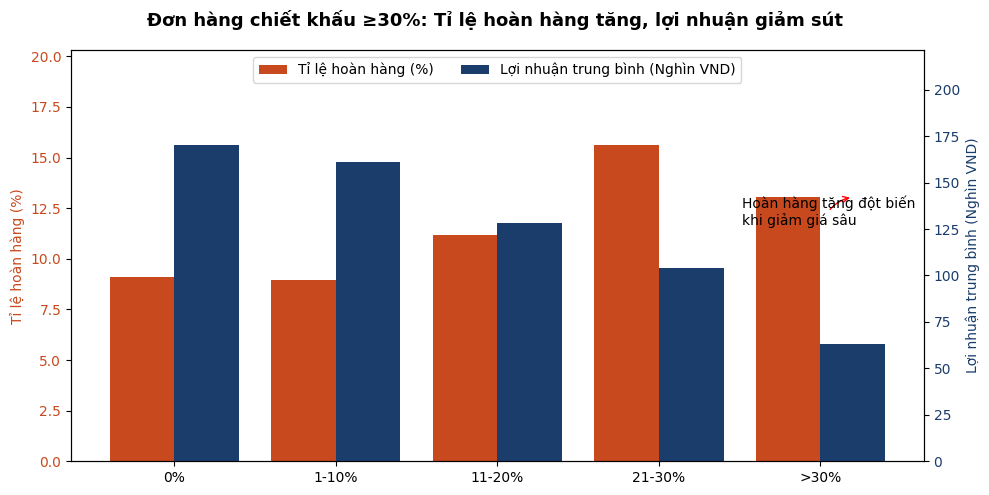

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Phân nhóm mức độ chiết khấu
bins = [-1, 0, 0.1, 0.2, 0.3, 1]
labels = ['0%', '1-10%', '11-20%', '21-30%', '>30%']
df['discount_tier'] = pd.cut(df['discount_pct'], bins=bins, labels=labels)

discount_stats = df.groupby('discount_tier', observed=False).agg(
    return_rate=('returned', 'mean'),
    avg_profit=('profit', 'mean')
)
discount_stats['return_rate'] *= 100

fig, ax1 = plt.subplots(figsize=(10, 5))

# Vẽ cột cho tỉ lệ hoàn hàng
bar_width = 0.4
x = np.arange(len(discount_stats))

ax1.bar(x - bar_width/2, discount_stats['return_rate'], width=bar_width, color='#C8491E', label='Tỉ lệ hoàn hàng (%)')
ax1.set_ylabel('Tỉ lệ hoàn hàng (%)', color='#C8491E')
ax1.tick_params(axis='y', labelcolor='#C8491E')
ax1.set_xticks(x)
ax1.set_xticklabels(discount_stats.index)

# Vẽ cột cho lợi nhuận trung bình trên trục y thứ hai
ax2 = ax1.twinx()
ax2.bar(x + bar_width/2, discount_stats['avg_profit'] / 1e3, width=bar_width, color='#1A3D6B', label='Lợi nhuận trung bình (Nghìn VND)')
ax2.set_ylabel('Lợi nhuận trung bình (Nghìn VND)', color='#1A3D6B')
ax2.tick_params(axis='y', labelcolor='#1A3D6B')

# Mở rộng không gian trục Y để không bị lấp legend
ax1.set_ylim(0, discount_stats['return_rate'].max() * 1.3)
ax2.set_ylim(0, (discount_stats['avg_profit'] / 1e3).max() * 1.3)

# Thêm chú giải (legend) cho biểu đồ 2 trục, đẩy lên phía giữa vùng trống
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', ncol=2)

# Annotation cho >30%
ax1.annotate('Hoàn hàng tăng đột biến\nkhi giảm giá sâu', xy=(4.2, discount_stats['return_rate'].iloc[4]), xycoords='data', xytext=(-80, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", color='red'))

fig.suptitle('Đơn hàng chiết khấu ≥30%: Tỉ lệ hoàn hàng tăng, lợi nhuận giảm sút', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**👉 Kết luận & Câu chuyện kinh doanh**
- **Kết luận:** Vượt qua ngưỡng giảm giá 30%, chất lượng đơn hàng đi xuống: tỷ lệ hoàn hàng đột ngột cao và lợi nhuận gần như bốc hơi.
- **Tính ứng dụng:** Việc cố gắng thúc đẩy doanh thu bằng cách giảm giá sâu không mang lại hiệu quả thực chất, ngược lại gia tăng tỷ lệ hoàn hàng dẫn đến doanh nghiệp chảy máu tài chính.

## 4. Top ngành hàng theo Lợi nhuận / Đơn hàng
**Headline:** Làm đẹp & Sức khỏe là ngành hàng có tỷ suất lợi nhuận trên mỗi đơn hàng cao nhất, xứng đáng là “con gà đẻ trứng vàng”.

💡 **Lựa chọn biểu đồ:**
- **Bar chart (Biểu đồ cột ngang):** Dễ dàng so sánh lợi nhuận trung bình của 1 đơn hàng theo các category.

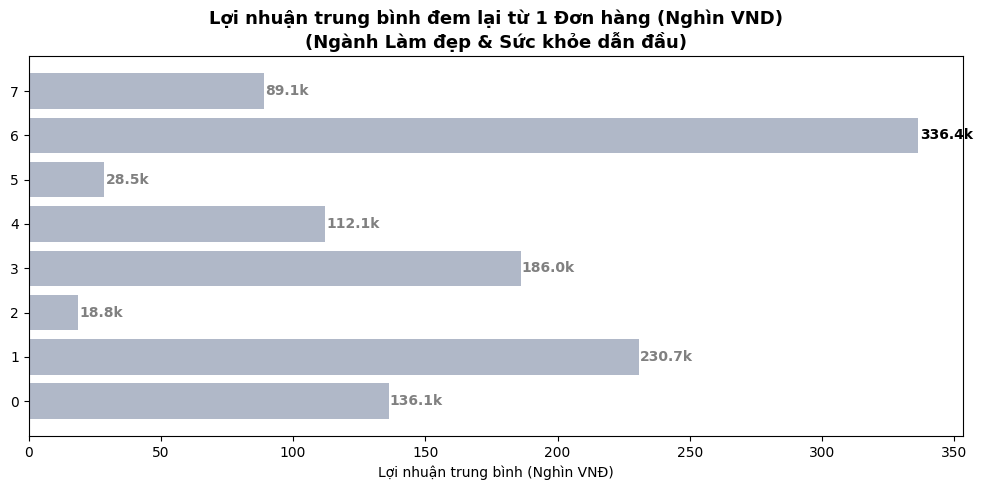

In [29]:
profit_per_order = (cat_stats['profit'] / cat_stats['orders']) / 1000  # Lợi nhuận VNĐ/đơn (Nghìn VNĐ)
profit_per_order = profit_per_order.sort_values(ascending=True)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#C8491E' if cat == 'Làm đẹp & Sức khỏe' else '#B0B8C8' for cat in profit_per_order.index]
bars = ax.barh(profit_per_order.index, profit_per_order.values, color=colors)

for bar, val in zip(bars, profit_per_order.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}k', va='center', fontweight='bold', color='black' if val == profit_per_order.max() else 'gray')

ax.set_title('Lợi nhuận trung bình đem lại từ 1 Đơn hàng (Nghìn VND)\n(Ngành Làm đẹp & Sức khỏe dẫn đầu)', fontsize=13, fontweight='bold')
ax.set_xlabel('Lợi nhuận trung bình (Nghìn VNĐ)')
plt.tight_layout()
plt.show()

**👉 Kết luận & Câu chuyện kinh doanh**
- **Kết luận:** Ngành mang lại lợi nhuận thực tế tốt nhất trên một đơn hàng lại là **Làm đẹp & Sức khỏe**, với hơn 40k VND/đơn hàng, vượt trội so với các ngành khác. 
- **Tính ứng dụng:** Bổ sung bằng chứng và khẳng định lại giả thuyết từ biểu đồ Scatter plot: Khối lượng giao dịch của Điện tử đang che mờ sự thật rằng Làm đẹp mới là mũi nhọn tối ưu lợi nhuận.

---
## 5. Slide cuối: Khuyến nghị đầu tư: Ngành hàng ưu tiên cho năm 2024
**Dựa trên bằng chứng Data 2023**

1. **Từ bỏ ảo tưởng doanh thu từ Điện tử:** Dù Điện tử có Total Revenue cao, Margin lại rất mỏng (S2) và hiệu suất biên LN/đơn ở nhóm dưới (Biểu đồ 4). Đừng gồng lỗ chiết khấu cho nhóm này!
2. **Siết lại chiến lược Khuyến Mãi:** Không giảm giá quá 30% một cách bừa bãi. Việc lạm dụng chiết khấu chỉ thu hút tập khách hàng dễ hoàn trả, làm tăng Return Rate (S3).
3. **Quản lý rủi ro Thời trang:** Ngành thời trang bị bài toán đau đầu là Hoàn hàng lên đến gần 20% (S5), ăn mòn trực tiếp vào tỷ suất lợi nhuận.
4. **CHỐT LẠI - Tập trung "Làm đẹp & Sức khỏe":** 
    - Có Profit Margin ấn tượng! (S2)
    - Mang lại Lợi nhuận/Đơn hàng tốt nhất! (Biểu đồ 4)
    - Rủi ro hoàn hàng ở mức lý tưởng, ít hơn Thời Trang rất nhiều (S5).
    **👉 Đề xuất: Dịch chuyển 30% ngân sách Marketing từ Điện tử sang việc tạo các gói Bundle/Combo và chạy Ads cho mỹ phẩm, sản phẩm làm đẹp trong năm 2024.**